Day 1 - EDA and Observations

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
base_path = '/content/drive/MyDrive/UserBehaviorML'

os.makedirs(os.path.join(base_path, 'data'), exist_ok=True)
os.makedirs(os.path.join(base_path, 'notebooks'), exist_ok=True)
os.makedirs(os.path.join(base_path, 'src'), exist_ok=True)

print("Carpetas creadas correctamente en:", base_path)

Carpetas creadas correctamente en: /content/drive/MyDrive/UserBehaviorML


import libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

Generate simulated dataset

In [4]:
np.random.seed(42)

num_users = 500
num_sessions = 1000

user_ids = np.random.choice(range(1, num_users+1), num_sessions)
session_length = np.random.exponential(scale=10, size=num_sessions)  # minutos
pages_viewed = np.random.poisson(lam=5, size=num_sessions)
time_per_page = session_length / (pages_viewed + 1)
actions_count = np.random.randint(1, 20, size=num_sessions)
device_type = np.random.choice(['mobile', 'desktop', 'tablet'], size=num_sessions)
time_of_day = np.random.choice(range(24), size=num_sessions)

df = pd.DataFrame({
    'user_id': user_ids,
    'session_length': session_length,
    'pages_viewed': pages_viewed,
    'time_per_page': time_per_page,
    'actions_count': actions_count,
    'device_type': device_type,
    'time_of_day': time_of_day
})

# Guardar dataset en carpeta /data
df.to_csv(os.path.join(base_path, 'data', 'user_behavior.csv'), index=False)
print("Dataset saved at  /data/user_behavior.csv")

Dataset saved at  /data/user_behavior.csv


Exploratory Data Analysis

First rows of the dataset:


,user_id,session_length,pages_viewed,time_per_page,actions_count,device_type,time_of_day
0,103,1.630095,4,0.326019,13,desktop,22
1,436,9.017241,5,1.502874,3,mobile,3
2,349,4.794737,5,0.799123,18,mobile,19
3,271,35.037086,5,5.839514,2,desktop,18
4,107,18.459132,6,2.637019,17,tablet,9



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         1000 non-null   int64  
 1   session_length  1000 non-null   float64
 2   pages_viewed    1000 non-null   int64  
 3   time_per_page   1000 non-null   float64
 4   actions_count   1000 non-null   int64  
 5   device_type     1000 non-null   object 
 6   time_of_day     1000 non-null   int64  
dtypes: float64(2), int64(4), object(1)
memory usage: 54.8+ KB
None

Descriptive statistics:


,user_id,session_length,pages_viewed,time_per_page,actions_count,time_of_day
count,1000.00000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,251.68300,10.007252,4.95900,1.981319,9.971000,11.659000
std,141.79995,10.231349,2.14007,2.513831,5.623859,6.900749
min,1.00000,0.046428,0.00000,0.008254,1.000000,0.000000
25%,134.75000,2.684554,3.00000,0.485298,5.000000,5.750000
50%,247.00000,6.897166,5.00000,1.191620,10.000000,12.000000
75%,374.00000,13.702197,6.00000,2.472155,15.000000,17.000000
max,500.00000,81.724456,12.00000,22.120799,19.000000,23.000000


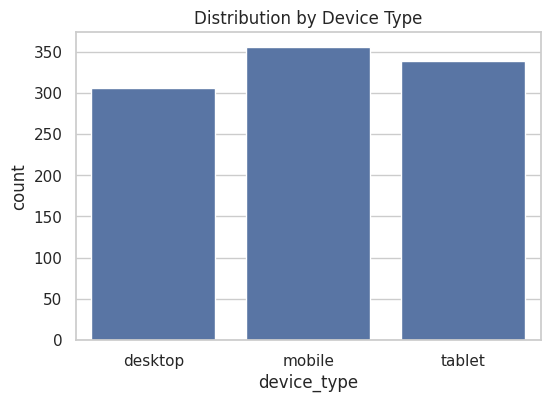

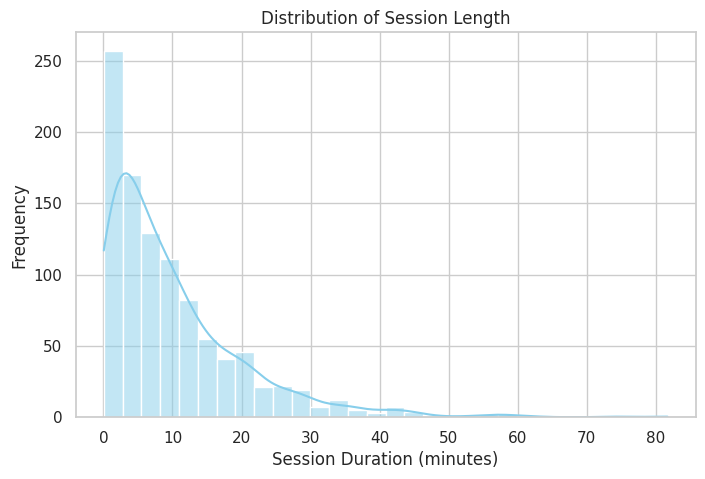

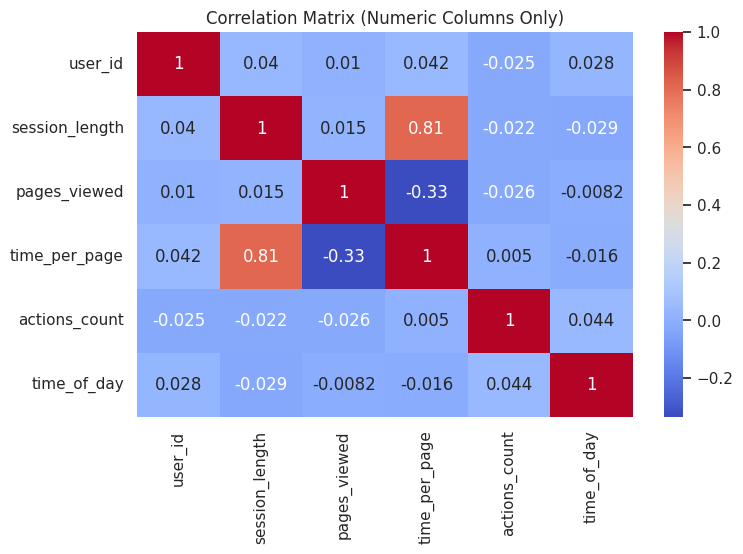

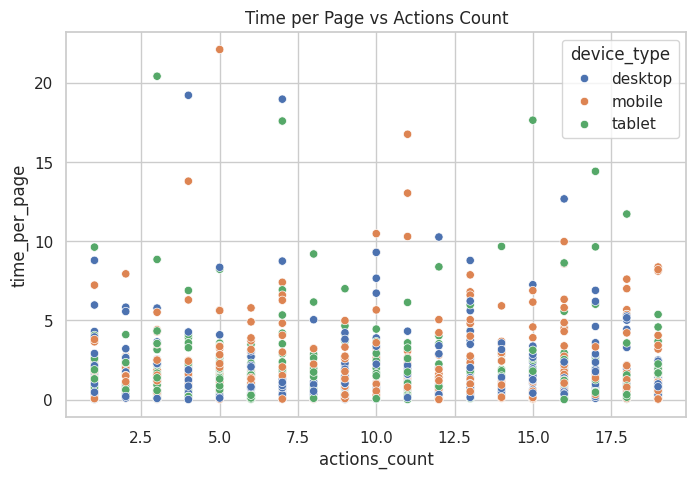

In [5]:
# 4a. Quick overview
print("First rows of the dataset:")
display(df.head())

print("\nDataset info:")
print(df.info())

print("\nDescriptive statistics:")
display(df.describe())

# 4b. Count of devices
plt.figure(figsize=(6,4))
sns.countplot(x='device_type', data=df)
plt.title("Distribution by Device Type")
plt.show()

# 4c. Histogram of session length
plt.figure(figsize=(8,5))
sns.histplot(df['session_length'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of Session Length")
plt.xlabel("Session Duration (minutes)")
plt.ylabel("Frequency")
plt.show()

#select one numeric column
numeric_cols= df.select_dtypes(include=np.number)
# 4d. Correlation matrix
plt.figure(figsize=(8,5))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix (Numeric Columns Only)")
plt.show()

# 4e. Scatter plot: time per page vs actions count
plt.figure(figsize=(8,5))
sns.scatterplot(x='actions_count', y='time_per_page', hue='device_type', data=df)
plt.title("Time per Page vs Actions Count")
plt.show()

Initial Observatios (Day 1 -EDA)

In [6]:
from IPython.display import Markdown, display

observations = """
### Initial Observations (EDA)

1. **Session length distribution is skewed** toward shorter sessions, with many users having brief interactions.
2. **Most users access the platform via mobile**, followed by desktop and tablet.
3. **Correlation analysis** shows that `session_length` is moderately related to `pages_viewed` and `actions_count`.
4. **Some users perform many actions but spend less time per page**, indicating fast navigation or possibly automated/bot-like behavior.
5. These insights suggest that **aggregated user-level features** can be created to enable clustering and segmentation in the next step.
"""

display(Markdown(observations))


### Initial Observations (EDA)

1. **Session length distribution is skewed** toward shorter sessions, with many users having brief interactions.
2. **Most users access the platform via mobile**, followed by desktop and tablet.
3. **Correlation analysis** shows that `session_length` is moderately related to `pages_viewed` and `actions_count`.
4. **Some users perform many actions but spend less time per page**, indicating fast navigation or possibly automated/bot-like behavior.
5. These insights suggest that **aggregated user-level features** can be created to enable clustering and segmentation in the next step.


Day 2 - Feature Engineering

In [7]:
#Path to dataset
base_path = '/content/drive/MyDrive/UserBehaviorML'
data_path = os.path.join(base_path, 'data', 'user_behavior.csv')

#Load dataset
df = pd.read_csv(data_path)
print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,user_id,session_length,pages_viewed,time_per_page,actions_count,device_type,time_of_day
0,103,1.630095,4,0.326019,13,desktop,22
1,436,9.017241,5,1.502874,3,mobile,3
2,349,4.794737,5,0.799123,18,mobile,19
3,271,35.037086,5,5.839514,2,desktop,18
4,107,18.459132,6,2.637019,17,tablet,9


Aggregate data by user

In [8]:
user_df = df.groupby('user_id').agg({
    'session_length': ['mean', 'max', 'min', 'sum'],
    'pages_viewed': ['mean', 'sum'],
    'time_per_page': 'mean',
    'actions_count': ['mean', 'sum'],
    'device_type': lambda x: x.mode()[0],  # most frequent device
    'time_of_day': ['mean']
})

#Flatten MultiIndex columns
user_df.columns = ['_'.join(col).strip() if type(col) is tuple else col for col in user_df.columns.values]
user_df.reset_index(inplace=True)

user_df.head()

,user_id,session_length_mean,session_length_max,session_length_min,session_length_sum,pages_viewed_mean,pages_viewed_sum,time_per_page_mean,actions_count_mean,actions_count_sum,device_type_<lambda>,time_of_day_mean
0,1,6.154734,11.496362,2.304719,18.464202,3.666667,11,1.269359,6.000000,18,desktop,4.666667
1,2,4.382669,8.327155,2.310922,13.148006,4.666667,14,0.754230,11.666667,35,mobile,16.333333
2,4,20.580977,34.698357,6.463598,41.161955,3.000000,6,4.507429,5.500000,11,desktop,6.500000
3,5,6.535220,12.662847,1.410656,26.140882,4.250000,17,1.313540,15.250000,61,desktop,14.500000
4,6,4.068319,4.068319,4.068319,4.068319,5.000000,5,0.678053,11.000000,11,tablet,21.000000


Create New Features

In [9]:
user_df['actions_per_page'] = user_df['actions_count_mean'] / (user_df['pages_viewed_mean'] + 1)
user_df['pages_per_session'] = user_df['pages_viewed_sum'] / (user_df['session_length_sum'] + 0.01)
user_df['engagement_score'] = user_df['actions_count_sum'] * user_df['session_length_mean']

user_df.head()

,user_id,session_length_mean,session_length_max,session_length_min,session_length_sum,pages_viewed_mean,pages_viewed_sum,time_per_page_mean,actions_count_mean,actions_count_sum,device_type_<lambda>,time_of_day_mean,actions_per_page,pages_per_session,engagement_score
0,1,6.154734,11.496362,2.304719,18.464202,3.666667,11,1.269359,6.000000,18,desktop,4.666667,1.285714,0.595425,110.785210
1,2,4.382669,8.327155,2.310922,13.148006,4.666667,14,0.754230,11.666667,35,mobile,16.333333,2.058824,1.063991,153.393408
2,4,20.580977,34.698357,6.463598,41.161955,3.000000,6,4.507429,5.500000,11,desktop,6.500000,1.375000,0.145730,226.390750
3,5,6.535220,12.662847,1.410656,26.140882,4.250000,17,1.313540,15.250000,61,desktop,14.500000,2.904762,0.650074,398.648450
4,6,4.068319,4.068319,4.068319,4.068319,5.000000,5,0.678053,11.000000,11,tablet,21.000000,1.833333,1.225995,44.751507


Encode Categorical Features

In [10]:
# One-hot encode the most frequent device
user_df = pd.get_dummies(user_df, columns=['device_type_<lambda>'], prefix='device')

user_df.head()

,user_id,session_length_mean,session_length_max,session_length_min,session_length_sum,pages_viewed_mean,pages_viewed_sum,time_per_page_mean,actions_count_mean,actions_count_sum,time_of_day_mean,actions_per_page,pages_per_session,engagement_score,device_desktop,device_mobile,device_tablet
0,1,6.154734,11.496362,2.304719,18.464202,3.666667,11,1.269359,6.000000,18,4.666667,1.285714,0.595425,110.785210,True,False,False
1,2,4.382669,8.327155,2.310922,13.148006,4.666667,14,0.754230,11.666667,35,16.333333,2.058824,1.063991,153.393408,False,True,False
2,4,20.580977,34.698357,6.463598,41.161955,3.000000,6,4.507429,5.500000,11,6.500000,1.375000,0.145730,226.390750,True,False,False
3,5,6.535220,12.662847,1.410656,26.140882,4.250000,17,1.313540,15.250000,61,14.500000,2.904762,0.650074,398.648450,True,False,False
4,6,4.068319,4.068319,4.068319,4.068319,5.000000,5,0.678053,11.000000,11,21.000000,1.833333,1.225995,44.751507,False,False,True


Save processed Dataset

In [11]:
# Save processed user-level dataset
processed_path = os.path.join(base_path, 'data', 'user_features.csv')
user_df.to_csv(processed_path, index=False)
print("Processed dataset saved at:", processed_path)

Processed dataset saved at: /content/drive/MyDrive/UserBehaviorML/data/user_features.csv


Day 3 - User Segmentation with Clustering

In [12]:
#Path to processed dataset from day 2
processed_path = os.path.join(base_path, 'data', 'user_features.csv')

#load dataset
user_df = pd.read_csv(processed_path)
print("Processed dataset loaded successfully!")
user_df.head()

Processed dataset loaded successfully!


,user_id,session_length_mean,session_length_max,session_length_min,session_length_sum,pages_viewed_mean,pages_viewed_sum,time_per_page_mean,actions_count_mean,actions_count_sum,time_of_day_mean,actions_per_page,pages_per_session,engagement_score,device_desktop,device_mobile,device_tablet
0,1,6.154734,11.496362,2.304719,18.464202,3.666667,11,1.269359,6.000000,18,4.666667,1.285714,0.595425,110.785210,True,False,False
1,2,4.382669,8.327155,2.310922,13.148006,4.666667,14,0.754230,11.666667,35,16.333333,2.058824,1.063991,153.393408,False,True,False
2,4,20.580977,34.698357,6.463598,41.161955,3.000000,6,4.507429,5.500000,11,6.500000,1.375000,0.145730,226.390750,True,False,False
3,5,6.535220,12.662847,1.410656,26.140882,4.250000,17,1.313540,15.250000,61,14.500000,2.904762,0.650074,398.648450,True,False,False
4,6,4.068319,4.068319,4.068319,4.068319,5.000000,5,0.678053,11.000000,11,21.000000,1.833333,1.225995,44.751507,False,False,True


Select features for clustering

In [13]:
#choose numeric columns for clustering
features = [
    'session_length_mean', 'session_length_max', 'session_length_min', 'session_length_sum',
    'pages_viewed_mean', 'pages_viewed_sum',
    'time_per_page_mean',
    'actions_count_mean', 'actions_count_sum',
    'actions_per_page', 'pages_per_session', 'engagement_score',
    'device_desktop', 'device_mobile', 'device_tablet'
]

X = user_df[features]
X.head()

,session_length_mean,session_length_max,session_length_min,session_length_sum,pages_viewed_mean,pages_viewed_sum,time_per_page_mean,actions_count_mean,actions_count_sum,actions_per_page,pages_per_session,engagement_score,device_desktop,device_mobile,device_tablet
0,6.154734,11.496362,2.304719,18.464202,3.666667,11,1.269359,6.000000,18,1.285714,0.595425,110.785210,True,False,False
1,4.382669,8.327155,2.310922,13.148006,4.666667,14,0.754230,11.666667,35,2.058824,1.063991,153.393408,False,True,False
2,20.580977,34.698357,6.463598,41.161955,3.000000,6,4.507429,5.500000,11,1.375000,0.145730,226.390750,True,False,False
3,6.535220,12.662847,1.410656,26.140882,4.250000,17,1.313540,15.250000,61,2.904762,0.650074,398.648450,True,False,False
4,4.068319,4.068319,4.068319,4.068319,5.000000,5,0.678053,11.000000,11,1.833333,1.225995,44.751507,False,False,True


scale the features

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Apply K-Means Clustering

In [15]:
from sklearn.cluster import KMeans

# Define number of clusters
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
user_df['cluster'] = kmeans.fit_predict(X_scaled)

user_df.head()

,user_id,session_length_mean,session_length_max,session_length_min,session_length_sum,pages_viewed_mean,pages_viewed_sum,time_per_page_mean,actions_count_mean,actions_count_sum,time_of_day_mean,actions_per_page,pages_per_session,engagement_score,device_desktop,device_mobile,device_tablet,cluster
0,1,6.154734,11.496362,2.304719,18.464202,3.666667,11,1.269359,6.000000,18,4.666667,1.285714,0.595425,110.785210,True,False,False,0
1,2,4.382669,8.327155,2.310922,13.148006,4.666667,14,0.754230,11.666667,35,16.333333,2.058824,1.063991,153.393408,False,True,False,0
2,4,20.580977,34.698357,6.463598,41.161955,3.000000,6,4.507429,5.500000,11,6.500000,1.375000,0.145730,226.390750,True,False,False,1
3,5,6.535220,12.662847,1.410656,26.140882,4.250000,17,1.313540,15.250000,61,14.500000,2.904762,0.650074,398.648450,True,False,False,2
4,6,4.068319,4.068319,4.068319,4.068319,5.000000,5,0.678053,11.000000,11,21.000000,1.833333,1.225995,44.751507,False,False,True,0


Visualize the Clusters

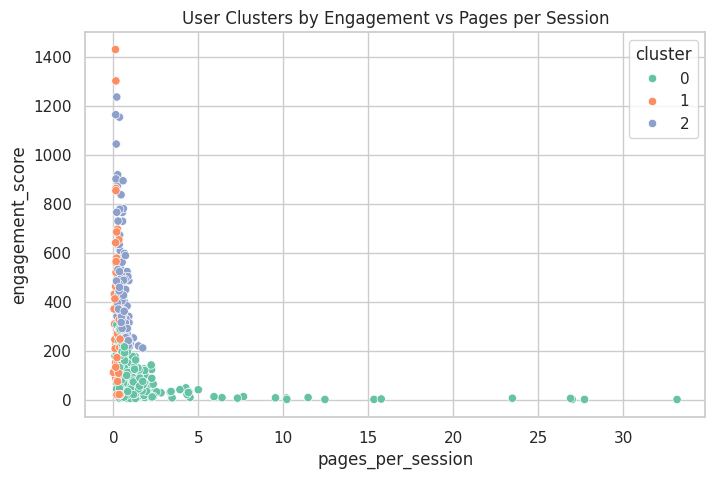

In [16]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='pages_per_session',
    y='engagement_score',
    hue='cluster',
    palette='Set2',
    data=user_df
)
plt.title("User Clusters by Engagement vs Pages per Session")
plt.show()

Analyze Cluster Characteristics

In [17]:
cluster_summary = user_df.groupby('cluster').mean()[features]
cluster_summary

,session_length_mean,session_length_max,session_length_min,session_length_sum,pages_viewed_mean,pages_viewed_sum,time_per_page_mean,actions_count_mean,actions_count_sum,actions_per_page,pages_per_session,engagement_score,device_desktop,device_mobile,device_tablet
cluster,,,,,,,,,,,,,,,
0,6.012314,8.000781,4.196281,10.897730,4.873663,9.012346,1.147584,9.528738,17.349794,1.818967,2.035558,97.457026,0.432099,0.325103,0.242798
1,23.519274,28.335574,19.312438,35.936679,4.760256,7.200000,4.961749,9.688462,14.507692,1.992024,0.221103,345.199232,0.307692,0.507692,0.184615
2,11.837212,23.319931,2.965860,43.680167,5.162422,20.008696,2.275099,10.827101,41.843478,1.856133,0.530112,464.820958,0.400000,0.330435,0.269565


Day 4 - Cluster Interpretation and advanced Visualizations

In [18]:
#Number of users per cluster
cluster_counts = user_df['cluster'].value_counts().sort_index()
cluster_counts

,count
cluster,
0,243
1,65
2,115


Visualized cluster distribution

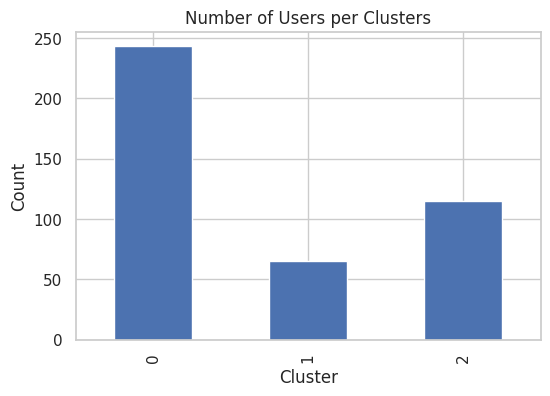

In [19]:
plt.figure(figsize=(6,4))
cluster_counts.plot(kind='bar')
plt.title("Number of Users per Clusters")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

Compare Key metrics across clusters


In [20]:
#Average behaviour metrics per cluster
cluster_profile = user_df.groupby('cluster')[[
    'session_length_mean',
    'pages_viewed_mean',
    'actions_count_mean',
    'engagement_score'
]].mean()

Heatmap of Cluster Profiles

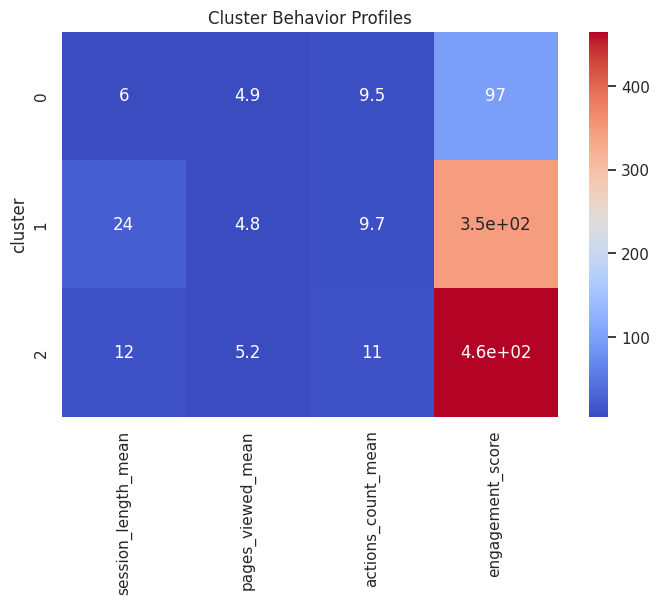

In [21]:
plt.figure(figsize=(8,5))
sns.heatmap(cluster_profile, annot=True, cmap='coolwarm')
plt.title("Cluster Behavior Profiles")
plt.show()

Label the clusters (interpretation)

In [22]:
# Manual interpretation of clusters
cluster_labels = {
    0: "Low Engagement Users",
    1: "Highly Engaged Users",
    2: "Fast Browsers"
}

user_df['cluster_label'] = user_df['cluster'].map(cluster_labels)
user_df[['user_id', 'cluster', 'cluster_label']].head()

,user_id,cluster,cluster_label
0,1,0,Low Engagement Users
1,2,0,Low Engagement Users
2,4,1,Highly Engaged Users
3,5,2,Fast Browsers
4,6,0,Low Engagement Users


Final visualization with cluster labels

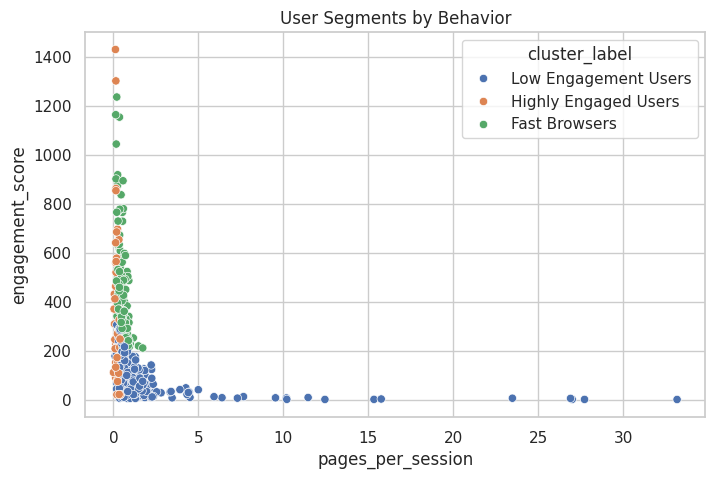

In [23]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='pages_per_session',
    y='engagement_score',
    hue='cluster_label',
    data=user_df
)
plt.title("User Segments by Behavior")
plt.show()